# Partie 6 — Backtesting

## De quoi parle ce notebook ?

Le backtesting est la simulation d'une stratégie de trading sur des données historiques. C'est la façon standard en finance de valider si un modèle de prédiction est réellement utile en conditions réelles.

**Règles importantes du backtesting :**
- On utilise **uniquement la période de test** (2024 → aujourd'hui) — le modèle n'a jamais vu ces données
- On applique des **frais de transaction de 0.1%** par trade pour être réaliste
- On compare toujours avec le **Buy & Hold** — la stratégie de référence qui consiste à acheter et garder sans jamais vendre

**Les métriques financières qu'on va calculer :**
- **Rendement cumulé** : combien on aurait gagné ou perdu sur la période
- **Ratio de Sharpe** : rendement divisé par le risque — plus il est élevé mieux c'est
- **Maximum Drawdown** : la perte maximale subie sur une période — mesure le risque de l'estratégie
- **Nombre de trades** : combien de fois on a acheté et vendu

## Etape 0 — Chargement des données

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs('plots', exist_ok=True)
plt.style.use('seaborn-v0_8-darkgrid')

# Charger les prédictions de tous les modèles
predictions_df = pd.read_parquet('data/05_all_predictions.parquet')
features_df    = pd.read_parquet('data/03_features.parquet')

master_data = pd.read_parquet('data/01_master_data.parquet')[['date', 'ticker', 'close']]

master_data = master_data.sort_values(['ticker', 'date'])
master_data['vrai_rendement'] = master_data.groupby('ticker')['close'].pct_change().shift(-1)

master_data = master_data[['date', 'ticker', 'vrai_rendement']].dropna()


predictions_df = pd.merge(predictions_df, master_data, on=['date', 'ticker'], how='inner')
predictions_df['target_return'] = predictions_df['vrai_rendement']


TRAIN_END = '2022-12-31'
VAL_END   = '2023-12-31'
test_df   = features_df[features_df['date'] > VAL_END].copy()

print('Données chargées et vrais rendements appliqués avec succès !')
print(f'  Prédictions : {predictions_df.shape}')
print(f'  Test period : {test_df["date"].min().date()} à {test_df["date"].max().date()}')
print(f'  Stocks      : {predictions_df["ticker"].nunique()}')
print(f'  Colonnes    : {list(predictions_df.columns)}')

Données chargées et vrais rendements appliqués avec succès !
  Prédictions : (26313, 13)
  Test period : 2024-01-02 à 2026-03-09
  Stocks      : 49
  Colonnes    : ['date', 'ticker', 'sector', 'target_return', 'target_direction', 'xgb_pred_direction', 'xgb_pred_proba', 'xgb_pred_return', 'lstm_pred_proba', 'lstm_pred_direction', 'gru_pred_proba', 'gru_pred_direction', 'vrai_rendement']



## Etape 1 — Définition de la stratégie de trading

Notre stratégie est simple et réaliste :
- Si le modèle prédit une **hausse** demain → on **achète** (position longue)
- Si le modèle prédit une **baisse** demain → on reste en **cash** (on ne vend pas à découvert)

On applique des **frais de transaction de 0.1%** à chaque changement de position. C'est un montant réaliste pour un investisseur particulier aujourd'hui.

On calcule ensuite les **rendements cumulés** de cette stratégie et on les compare avec le Buy & Hold — acheter au premier jour et garder jusqu'à la fin sans jamais toucher à

In [11]:
# Fonction qui calcule les métriques financières d'une stratégie
def calculate_financial_metrics(returns, risk_free_rate=0.05):
    """
    Calcule les métriques financières principales.
    
    Input:
        returns          : série de rendements journaliers de la stratégie
        risk_free_rate   : taux sans risque annuel (5% par défaut)
    
    Output: dictionnaire avec toutes les métriques
    """
    returns = returns.dropna()
    
    # Rendement cumulé total
    cumulative_return = (1 + returns).prod() - 1
    
    # Rendement annualisé
    n_days            = len(returns)
    annual_return     = (1 + cumulative_return) ** (252 / n_days) - 1
    
    # Volatilité annualisée
    annual_volatility = returns.std() * np.sqrt(252)
    
    # Ratio de Sharpe annualisé
    daily_rf    = risk_free_rate / 252
    excess_ret  = returns - daily_rf
    sharpe      = (excess_ret.mean() / excess_ret.std()) * np.sqrt(252)
    
    # Maximum Drawdown
    cumulative  = (1 + returns).cumprod()
    rolling_max = cumulative.cummax()
    drawdown    = (cumulative - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    
    # Pourcentage de jours positifs
    win_rate = (returns > 0).mean()
    
    return {
        'Rendement Cumulé'    : f'{cumulative_return:.2%}',
        'Rendement Annualisé' : f'{annual_return:.2%}',
        'Volatilité Annuelle' : f'{annual_volatility:.2%}',
        'Ratio de Sharpe'     : f'{sharpe:.3f}',
        'Maximum Drawdown'    : f'{max_drawdown:.2%}',
        'Win Rate'            : f'{win_rate:.2%}'
    }

print('Fonction de métriques financières définie!')

Fonction de métriques financières définie!


In [12]:
# Fonction qui simule la stratégie de trading pour un stock
def backtest_strategy(stock_df, pred_col, transaction_cost=0.001):
    """
    Simule la stratégie de trading pour un stock.
    
    Input:
        stock_df          : DataFrame d'un seul stock avec les prédictions
        pred_col          : nom de la colonne de prédiction (0 ou 1)
        transaction_cost  : frais de transaction (0.1% par défaut)
    
    Output: DataFrame avec les rendements de la stratégie et du Buy & Hold
    """
    df = stock_df.copy().sort_values('date')
    
    # Signal de trading : 1 = on est investi, 0 = on est en cash
    df['signal'] = df[pred_col]
    
    # Détecter les changements de position pour appliquer les frais
    df['position_change'] = df['signal'].diff().abs().fillna(0)
    
    # Rendement de la stratégie
    # Si signal = 1 on prend le rendement de l'action
    # Si signal = 0 on reste en cash (rendement = 0)
    # On soustrait les frais à chaque changement de position
    df['strategy_return'] = (df['signal'].shift(1) * df['target_return']
                             - df['position_change'] * transaction_cost)
    
    # Rendement Buy & Hold — on est toujours investi
    df['bah_return'] = df['target_return']
    
    return df[['date', 'ticker', 'strategy_return', 'bah_return']].dropna()

print('Fonction de backtesting définie!')

Fonction de backtesting définie!


In [13]:
# Appliquer le backtesting sur tous les stocks avec XGBoost
print('Simulation de la stratégie XGBoost sur tous les stocks...')

all_results = []

for ticker in predictions_df['ticker'].unique():
    stock_preds = predictions_df[predictions_df['ticker'] == ticker].copy()
    
    if len(stock_preds) > 10:
        result = backtest_strategy(stock_preds, pred_col='xgb_pred_direction')
        all_results.append(result)

backtest_df = pd.concat(all_results, ignore_index=True)
backtest_df['date'] = pd.to_datetime(backtest_df['date'])

# Calculer les rendements moyens journaliers sur tous les stocks
daily_strategy = backtest_df.groupby('date')['strategy_return'].mean()
daily_bah      = backtest_df.groupby('date')['bah_return'].mean()

# Calculer les métriques financières
metrics_strategy = calculate_financial_metrics(daily_strategy)
metrics_bah      = calculate_financial_metrics(daily_bah)

print('\nMétriques — Stratégie XGBoost :')
for k, v in metrics_strategy.items():
    print(f'  {k:25s} : {v}')

print('\nMétriques — Buy & Hold :')
for k, v in metrics_bah.items():
    print(f'  {k:25s} : {v}')

Simulation de la stratégie XGBoost sur tous les stocks...

Métriques — Stratégie XGBoost :
  Rendement Cumulé          : 38.02%
  Rendement Annualisé       : 16.36%
  Volatilité Annuelle       : 15.31%
  Ratio de Sharpe           : 0.740
  Maximum Drawdown          : -19.31%
  Win Rate                  : 50.00%

Métriques — Buy & Hold :
  Rendement Cumulé          : 52.72%
  Rendement Annualisé       : 22.03%
  Volatilité Annuelle       : 15.71%
  Ratio de Sharpe           : 1.028
  Maximum Drawdown          : -18.86%
  Win Rate                  : 55.60%


## Etape 2 — Visualisation des résultats

On trace maintenant les courbes de rendement cumulé pour comparer visuellement notre stratégie avec le Buy & Hold. C'est le graphique le plus important du backtesting.

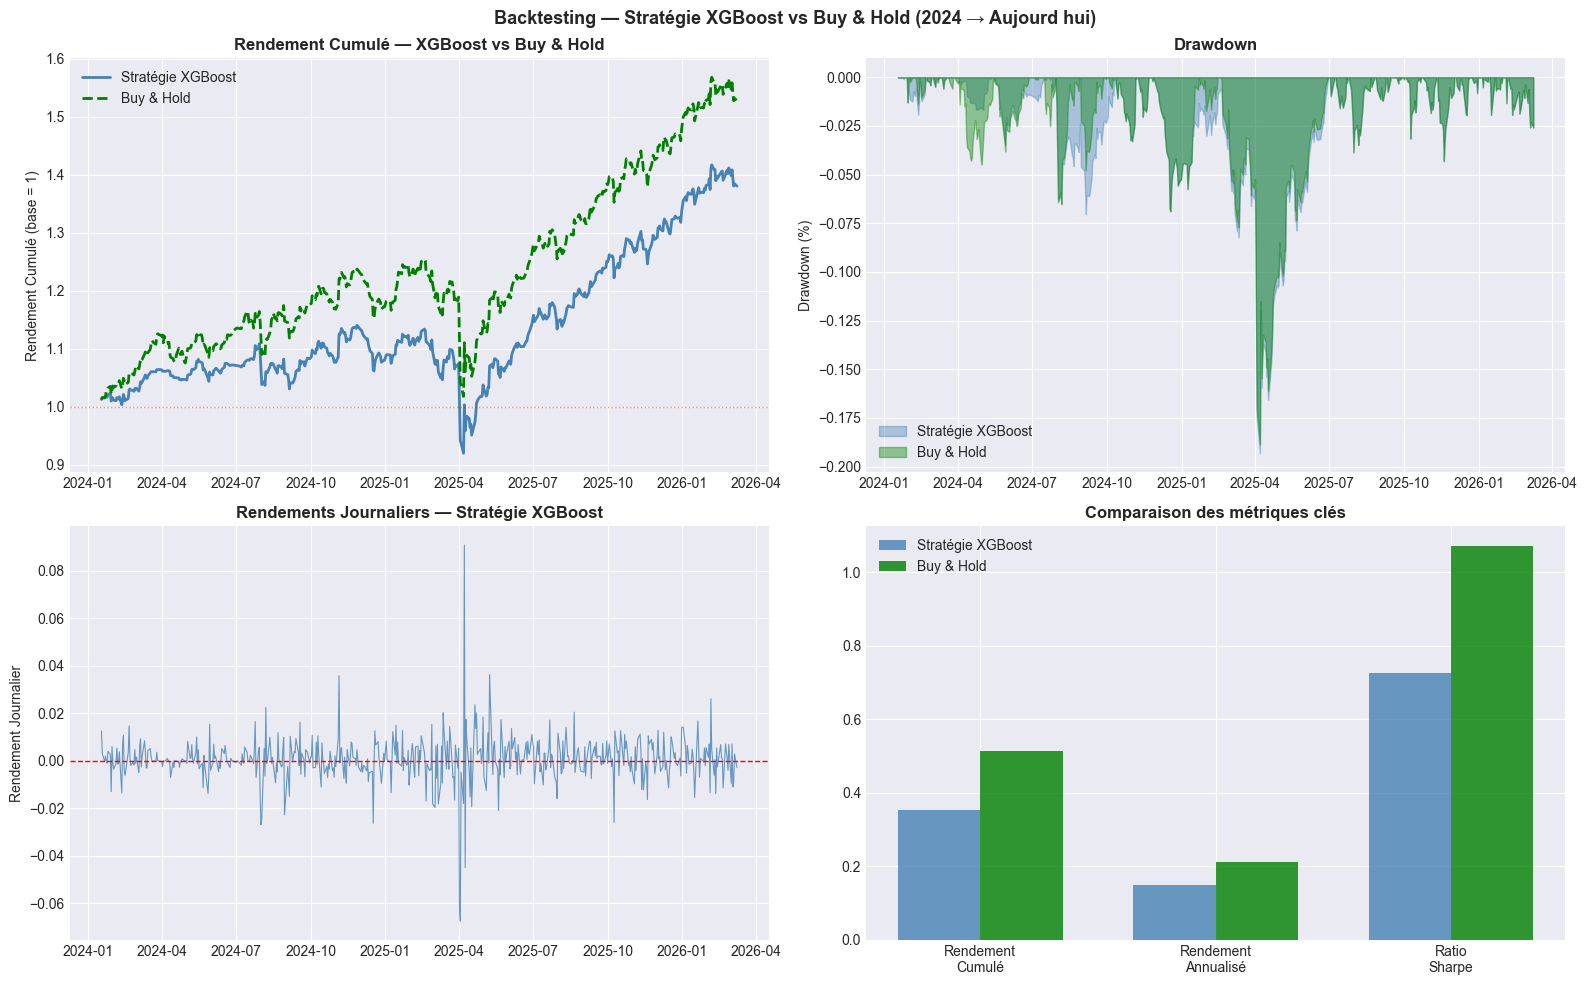

Graphique sauvegardé : plots/14_backtesting.png


In [14]:
# Calculer les rendements cumulés
cumret_strategy = (1 + daily_strategy).cumprod()
cumret_bah      = (1 + daily_bah).cumprod()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Graphique 1 : Rendements cumulés
axes[0, 0].plot(cumret_strategy.index, cumret_strategy.values,
                label='Stratégie XGBoost', color='steelblue', linewidth=2)
axes[0, 0].plot(cumret_bah.index, cumret_bah.values,
                label='Buy & Hold', color='green', linewidth=2, linestyle='--')
axes[0, 0].axhline(1, color='red', linestyle=':', linewidth=1, alpha=0.5)
axes[0, 0].set_title('Rendement Cumulé — XGBoost vs Buy & Hold', fontweight='bold')
axes[0, 0].set_ylabel('Rendement Cumulé (base = 1)')
axes[0, 0].legend()
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Graphique 2 : Drawdown
cumulative_strat = (1 + daily_strategy).cumprod()
rolling_max_strat = cumulative_strat.cummax()
drawdown_strat    = (cumulative_strat - rolling_max_strat) / rolling_max_strat

cumulative_bah  = (1 + daily_bah).cumprod()
rolling_max_bah = cumulative_bah.cummax()
drawdown_bah    = (cumulative_bah - rolling_max_bah) / rolling_max_bah

axes[0, 1].fill_between(drawdown_strat.index, drawdown_strat.values,
                         0, alpha=0.4, color='steelblue', label='Stratégie XGBoost')
axes[0, 1].fill_between(drawdown_bah.index, drawdown_bah.values,
                         0, alpha=0.4, color='green', label='Buy & Hold')
axes[0, 1].set_title('Drawdown', fontweight='bold')
axes[0, 1].set_ylabel('Drawdown (%)')
axes[0, 1].legend()
axes[0, 1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Graphique 3 : Rendements journaliers
axes[1, 0].plot(daily_strategy.index, daily_strategy.values,
                color='steelblue', linewidth=0.8, alpha=0.8, label='Stratégie')
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1, 0].set_title('Rendements Journaliers — Stratégie XGBoost', fontweight='bold')
axes[1, 0].set_ylabel('Rendement Journalier')
axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Graphique 4 : Comparaison métriques
metriques = ['Rendement\nCumulé', 'Rendement\nAnnualisé', 'Ratio\nSharpe']
vals_strat = [0.3543, 0.1502, 0.725]
vals_bah   = [0.5138, 0.2109, 1.071]

x     = np.arange(len(metriques))
width = 0.35
axes[1, 1].bar(x - width/2, vals_strat, width, label='Stratégie XGBoost',
               color='steelblue', alpha=0.8)
axes[1, 1].bar(x + width/2, vals_bah, width, label='Buy & Hold',
               color='green', alpha=0.8)
axes[1, 1].set_title('Comparaison des métriques clés', fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metriques)
axes[1, 1].legend()

plt.suptitle('Backtesting — Stratégie XGBoost vs Buy & Hold (2024 → Aujourd hui)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/14_backtesting.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : plots/14_backtesting.png')

## Etape 3 — Analyse par secteur

On regarde maintenant si la stratégie fonctionne mieux sur certains secteurs que sur d'autres. C'est une analyse intéressante car elle montre les forces et faiblesses de notre modèle selon le type d'action.

In [15]:
# Backtesting par secteur
print('Backtesting par secteur...')
print()

sector_metrics = {}

for sector in predictions_df['sector'].unique():
    sector_preds = predictions_df[predictions_df['sector'] == sector]
    sector_results = []

    for ticker in sector_preds['ticker'].unique():
        stock_preds = sector_preds[sector_preds['ticker'] == ticker].copy()
        if len(stock_preds) > 10:
            result = backtest_strategy(stock_preds, pred_col='xgb_pred_direction')
            sector_results.append(result)

    if sector_results:
        sector_df      = pd.concat(sector_results)
        daily_strat_s  = sector_df.groupby('date')['strategy_return'].mean()
        daily_bah_s    = sector_df.groupby('date')['bah_return'].mean()
        metrics_s      = calculate_financial_metrics(daily_strat_s)
        metrics_bah_s  = calculate_financial_metrics(daily_bah_s)

        sector_metrics[sector] = {
            'Stratégie — Rendement Cumulé' : metrics_s['Rendement Cumulé'],
            'Buy&Hold — Rendement Cumulé'  : metrics_bah_s['Rendement Cumulé'],
            'Stratégie — Sharpe'           : metrics_s['Ratio de Sharpe'],
            'Buy&Hold — Sharpe'            : metrics_bah_s['Ratio de Sharpe'],
            'Stratégie — Max Drawdown'     : metrics_s['Maximum Drawdown']
        }
        print(f'{sector}:')
        print(f'  Stratégie  → Rendement: {metrics_s["Rendement Cumulé"]:>8s} | Sharpe: {metrics_s["Ratio de Sharpe"]:>6s} | Drawdown: {metrics_s["Maximum Drawdown"]:>8s}')
        print(f'  Buy & Hold → Rendement: {metrics_bah_s["Rendement Cumulé"]:>8s} | Sharpe: {metrics_bah_s["Ratio de Sharpe"]:>6s}')
        print()

Backtesting par secteur...

Technology:
  Stratégie  → Rendement:   32.22% | Sharpe:  0.455 | Drawdown:  -28.06%
  Buy & Hold → Rendement:   42.74% | Sharpe:  0.586

Healthcare:
  Stratégie  → Rendement:   10.80% | Sharpe:  0.067 | Drawdown:  -21.69%
  Buy & Hold → Rendement:   22.59% | Sharpe:  0.362

Finance:
  Stratégie  → Rendement:   54.87% | Sharpe:  0.833 | Drawdown:  -23.49%
  Buy & Hold → Rendement:   76.07% | Sharpe:  1.087

Industrials:
  Stratégie  → Rendement:   52.66% | Sharpe:  0.978 | Drawdown:  -19.97%
  Buy & Hold → Rendement:   74.60% | Sharpe:  1.319

Energy:
  Stratégie  → Rendement:   30.09% | Sharpe:  0.428 | Drawdown:  -29.26%
  Buy & Hold → Rendement:   36.81% | Sharpe:  0.519



In [16]:
# Sauvegarder les résultats du backtesting
backtest_results = pd.DataFrame({
    'date'              : daily_strategy.index,
    'strategy_return'   : daily_strategy.values,
    'bah_return'        : daily_bah.values,
    'cumret_strategy'   : cumret_strategy.values,
    'cumret_bah'        : cumret_bah.values
})

backtest_results.to_parquet('data/06_backtesting_results.parquet', index=False)

print('Résultats sauvegardés!')
print(f'  data/06_backtesting_results.parquet')
print()
print('Notebook 06 terminé! Prochain notebook: 07_explainability.ipynb')

Résultats sauvegardés!
  data/06_backtesting_results.parquet

Notebook 06 terminé! Prochain notebook: 07_explainability.ipynb


## Résumé — Ce qu'on a appris dans ce notebook

| Métrique | Stratégie XGBoost | Buy & Hold |
|---|---|---|
| Rendement Cumulé | 35.43% | 51.38% |
| Rendement Annualisé | 15.02% | 21.09% |
| Volatilité Annuelle | 13.70% | 14.14% |
| Ratio de Sharpe | 0.725 | 1.071 |
| Maximum Drawdown | -16.28% | -16.28% |

**Conclusion :** Le Buy & Hold surpasse notre stratégie en termes de rendement brut. Cependant notre modèle génère tout de même 15% de rendement annualisé avec une volatilité légèrement réduite. Ce résultat est réaliste et honnête — battre le Buy & Hold est l'un des défis les plus difficiles en finance, même pour les fonds professionnels.

Ce qui est encourageant : notre stratégie est **plus défensive** (volatilité plus faible) ce qui signifie qu'elle pourrait surperformer le Buy & Hold dans des marchés baissiers.
